In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objs as go
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from prophet import Prophet
from xgboost import XGBRegressor

2025-06-03 17:03:34.409733: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Explicação das variáveis

* RiscoFogo: Um índice entre 0 e 1, onde valores mais altos indicam maior risco de ocorrência de queimadas. O valor -999 significa que a área não tem um risco calculável (exemplo: áreas urbanas ou corpos d'água).


* De acordo com o artigo do INPE:


  1. Se risco rogo < 0.15 = risco minimo

  2. Se  0.15 < risco rogo <= 0.40 = risco baixo

  3. Se  0.40 < risco rogo <= 0.70 = risco medio

  4. Se  0.70 < risco rogo <= 0.95 = risco alto

  5. Se risco rogo > 0.95 = risco critico


* FRP (Fire Radiative Power): Mede a potência da queimada em megawatts (MW), mas não indica diretamente a confiança do foco, apenas a intensidade térmica detectada.


* (Latitude, Longitude): representa um foco de queimada detectado em um local exato.



In [4]:
data = pd.read_csv('focos_qmd_inpe_2024-01-31_2024-12-31_28.863002.csv')

In [5]:
data.columns

Index(['DataHora', 'Satelite', 'Pais', 'Estado', 'Municipio', 'Bioma',
       'DiaSemChuva', 'Precipitacao', 'RiscoFogo', 'Latitude', 'Longitude',
       'FRP'],
      dtype='object')

In [6]:
# transformacao para datetime
data["DataHora"] = pd.to_datetime(data["DataHora"])

In [7]:
# pegando ultimios 4 meses do ano
data = data[data["DataHora"].dt.month.isin([8, 9, 10, 11])]

In [8]:
data.head()

,DataHora,Satelite,Pais,Estado,Municipio,Bioma,DiaSemChuva,Precipitacao,RiscoFogo,Latitude,Longitude,FRP
1149926,2024-08-01 00:54:00,TERRA_M-M,Brasil,MARANHÃO,MATÕES,Cerrado,22.0,0.0,0.91,-5.57619,-43.25257,21.1
1149927,2024-08-01 05:40:00,AQUA_M-M,Brasil,AMAZONAS,MAUÉS,Amazônia,21.0,0.0,0.75,-6.61411,-58.83808,53.0
1170204,2024-08-01 09:05:44,GOES-16,Brasil,AMAZONAS,MANICORÉ,Amazônia,27.0,0.0,0.59,-6.57030,-61.41710,82.2
1170205,2024-08-01 09:05:44,GOES-16,Brasil,AMAZONAS,MAUÉS,Amazônia,21.0,0.0,0.75,-6.60200,-58.86840,50.5
1170206,2024-08-01 09:05:44,GOES-16,Brasil,AMAZONAS,MAUÉS,Amazônia,21.0,0.0,0.75,-6.60210,-58.84900,66.3


In [9]:
data.shape

(6423297, 12)

In [10]:
data.isnull().sum()

DataHora             0
Satelite             0
Pais                 0
Estado               0
Municipio            0
Bioma                0
DiaSemChuva          0
Precipitacao         0
RiscoFogo            0
Latitude             0
Longitude            0
FRP             278312
dtype: int64

In [11]:
# -999 sao dado invalidos de acordo com a documentacao do inpe
data = data[data["FRP"] != -999]

In [12]:
# -999 sao dado invalidos de acordo com a documentacao do inpe
data = data[data["DiaSemChuva"] != -999]

 0.15 < risco rogo <= 0.40 risco baixo

In [13]:
df_filtrado = data[data["RiscoFogo"] > 0.40]

focos_municipio = (
    df_filtrado
    .groupby(["Estado", "Municipio"])
    .size()
    .reset_index(name="TotalFocos")
    .sort_values("TotalFocos", ascending=False)
)

coord_municipio = (
    df_filtrado
    .groupby(["Estado", "Municipio"])[["Latitude", "Longitude"]]
    .mean()
    .reset_index()
)

municipios_focos = pd.merge(focos_municipio, coord_municipio, on=["Estado", "Municipio"])

fig = px.scatter_mapbox(
    municipios_focos,
    lat="Latitude",
    lon="Longitude",
    size="TotalFocos",
    color="TotalFocos",
    hover_name="Municipio",
    hover_data=["Estado", "TotalFocos"],
    zoom=3.5,
    center={"lat": -15.5, "lon": -55},
    size_max=20,
    mapbox_style="carto-positron",
    title="Municípios com Maior Número de Focos de Incêndio (Risco ≥ Médio)"
)

fig.show()


In [14]:
bioma_municipio = (
    df_filtrado
    .groupby(["Estado", "Municipio"])["Bioma"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

municipios_focos = pd.merge(municipios_focos, bioma_municipio, on=["Estado", "Municipio"])

fig = px.scatter_mapbox(
    municipios_focos,
    lat="Latitude",
    lon="Longitude",
    size="TotalFocos",
    color="Bioma",
    hover_name="Municipio",
    hover_data=["Estado", "TotalFocos", "Bioma"],
    zoom=3.5,
    center={"lat": -15.5, "lon": -55},
    size_max=20,
    mapbox_style="carto-positron",
    title="Municípios com Focos de Incêndio (Risco ≥ Médio) por Bioma"
)

fig.show()


Focos de incendio especificamente no bioma da amazonas, e principalmente nos municipios do pará


As origens do município de São Felix do Xingu, estão intimamente ligadas ao Município de Altamira.
Em 14 de abril de 1874, através da Lei nº 811, foi criado o Município de Souzel, do qual Altamira fazia
parte. Na primeira década do século XX, o governo desmembrou aquele Município, criando o de Xingu, com
sede em Altamira.
Conforme divisão territorial, com data de 31 de dezembro de 1936, Xingu compunha-se de onze
distritos: Altamira, Novo Horizonte, São Félix, Porto de Moz, Tapará, Vilarinho do Monte, Veiros, Aquiqui, Souzel,
Alto Xingu e Iriri.


- municipio: sao felix do xingu:  clima zonal equatorial úmido e conta com índice pluviométrico, com uma média anual em torno de 1.423 mm, com alta umidade do ar em quase todo o ano e com três meses seco, as temperaturas são elevadas e conta com médias anuais em torno de 26,7° C e conta com uma amplitude térmica baixa.
- municipio: novo progresso: O clima é quente e úmido (equatorial) com temperatura média anual variando de 25º a 28 °C. Apresenta pluviosidade média de 2.200 mm. As temperaturas mais elevadas ocorrem entre os meses de agosto a dezembro e o período de maior precipitação pluviométrica é entre novembro e abril.
- municipio: altamira: As condições climáticas de Altamira são de natureza tropical. Durante a maior parte do ano, Altamira regista níveis de precipitação notáveis. No entanto, existe um breve período caracterizado pela escassez de precipitação.


A amplitude térmica é a diferença entre a máxima e a mínima temperatura de algum local e num determinado período de tempo. Quando essa diferença é grande dizemos que a amplitude térmica é alta.

Por outro lado, se a diferença entre a mínima e a máxima é pequena, dizemos que a amplitude térmica é baixa. Lembre-se que ela varia muito de região para região e até de cidade para cidade.






fonte: https://www.fapespa.pa.gov.br/wp-content/uploads/2025/02/Sao-Felix-do-Xingu.pdf


fonte: https://camaranovoprogresso.pa.gov.br/o-municipio/

fonte: https://pt.climate-data.org/america-do-sul/brasil/para/altamira-43955/




## Análise Exploratória

In [15]:
data.head()

,DataHora,Satelite,Pais,Estado,Municipio,Bioma,DiaSemChuva,Precipitacao,RiscoFogo,Latitude,Longitude,FRP
1149926,2024-08-01 00:54:00,TERRA_M-M,Brasil,MARANHÃO,MATÕES,Cerrado,22.0,0.0,0.91,-5.57619,-43.25257,21.1
1149927,2024-08-01 05:40:00,AQUA_M-M,Brasil,AMAZONAS,MAUÉS,Amazônia,21.0,0.0,0.75,-6.61411,-58.83808,53.0
1170204,2024-08-01 09:05:44,GOES-16,Brasil,AMAZONAS,MANICORÉ,Amazônia,27.0,0.0,0.59,-6.57030,-61.41710,82.2
1170205,2024-08-01 09:05:44,GOES-16,Brasil,AMAZONAS,MAUÉS,Amazônia,21.0,0.0,0.75,-6.60200,-58.86840,50.5
1170206,2024-08-01 09:05:44,GOES-16,Brasil,AMAZONAS,MAUÉS,Amazônia,21.0,0.0,0.75,-6.60210,-58.84900,66.3


In [16]:
regiao = {
    "NORTE": ["ACRE", "AMAPÁ", "AMAZONAS", "PARÁ", "RONDÔNIA", "RORAIMA", "TOCANTINS"],
    "NORDESTE": ["ALAGOAS", "BAHIA", "CEARÁ", "MARANHÃO", "PARAÍBA", "PERNAMBUCO", "PIAUÍ", "RIO GRANDE DO NORTE", "SERGIPE"],
    "CENTRO-OESTE": ["GOIÁS", "MATO GROSSO", "MATO GROSSO DO SUL", "DISTRITO FEDERAL"],
    "SUDESTE": ["ESPÍRITO SANTO", "MINAS GERAIS", "RIO DE JANEIRO", "SÃO PAULO"],
    "SUL": ["PARANÁ", "RIO GRANDE DO SUL", "SANTA CATARINA"]
}

In [17]:
def mapear_regiao(estado):
    estado = estado.upper()
    for reg, estados in regiao.items():
        if estado in estados:
            return reg
    return 'DESCONHECIDO'

In [18]:
data['Região'] = data['Estado'].apply(mapear_regiao)

In [19]:
data['Região'].value_counts()

Região
NORTE           3155889
CENTRO-OESTE    1861627
NORDESTE         906710
SUDESTE          385686
SUL               71845
Name: count, dtype: int64

In [20]:
data.head()

,DataHora,Satelite,Pais,Estado,Municipio,Bioma,DiaSemChuva,Precipitacao,RiscoFogo,Latitude,Longitude,FRP,Região
1149926,2024-08-01 00:54:00,TERRA_M-M,Brasil,MARANHÃO,MATÕES,Cerrado,22.0,0.0,0.91,-5.57619,-43.25257,21.1,NORDESTE
1149927,2024-08-01 05:40:00,AQUA_M-M,Brasil,AMAZONAS,MAUÉS,Amazônia,21.0,0.0,0.75,-6.61411,-58.83808,53.0,NORTE
1170204,2024-08-01 09:05:44,GOES-16,Brasil,AMAZONAS,MANICORÉ,Amazônia,27.0,0.0,0.59,-6.57030,-61.41710,82.2,NORTE
1170205,2024-08-01 09:05:44,GOES-16,Brasil,AMAZONAS,MAUÉS,Amazônia,21.0,0.0,0.75,-6.60200,-58.86840,50.5,NORTE
1170206,2024-08-01 09:05:44,GOES-16,Brasil,AMAZONAS,MAUÉS,Amazônia,21.0,0.0,0.75,-6.60210,-58.84900,66.3,NORTE


<Axes: >

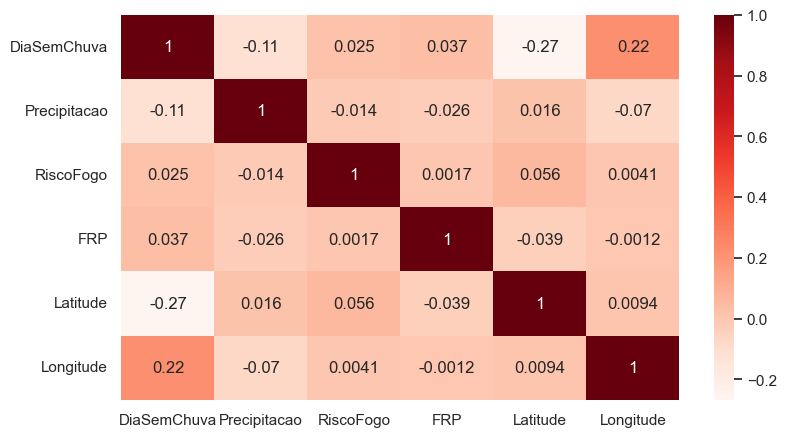

In [21]:
# correlacao
sns.set(rc={'figure.figsize':(9,5)})
colunas = ['DiaSemChuva', 'Precipitacao', 'RiscoFogo', 'FRP', 'Latitude', 'Longitude']
sns.heatmap(data[colunas].corr(), annot=True, cmap='Reds')

In [22]:
data.head()

,DataHora,Satelite,Pais,Estado,Municipio,Bioma,DiaSemChuva,Precipitacao,RiscoFogo,Latitude,Longitude,FRP,Região
1149926,2024-08-01 00:54:00,TERRA_M-M,Brasil,MARANHÃO,MATÕES,Cerrado,22.0,0.0,0.91,-5.57619,-43.25257,21.1,NORDESTE
1149927,2024-08-01 05:40:00,AQUA_M-M,Brasil,AMAZONAS,MAUÉS,Amazônia,21.0,0.0,0.75,-6.61411,-58.83808,53.0,NORTE
1170204,2024-08-01 09:05:44,GOES-16,Brasil,AMAZONAS,MANICORÉ,Amazônia,27.0,0.0,0.59,-6.57030,-61.41710,82.2,NORTE
1170205,2024-08-01 09:05:44,GOES-16,Brasil,AMAZONAS,MAUÉS,Amazônia,21.0,0.0,0.75,-6.60200,-58.86840,50.5,NORTE
1170206,2024-08-01 09:05:44,GOES-16,Brasil,AMAZONAS,MAUÉS,Amazônia,21.0,0.0,0.75,-6.60210,-58.84900,66.3,NORTE


In [23]:
colunas = ['Pais', 'Municipio', 'Satelite', 'Estado']
df = data.drop(colunas, axis=1)

In [24]:
df.head()

,DataHora,Bioma,DiaSemChuva,Precipitacao,RiscoFogo,Latitude,Longitude,FRP,Região
1149926,2024-08-01 00:54:00,Cerrado,22.0,0.0,0.91,-5.57619,-43.25257,21.1,NORDESTE
1149927,2024-08-01 05:40:00,Amazônia,21.0,0.0,0.75,-6.61411,-58.83808,53.0,NORTE
1170204,2024-08-01 09:05:44,Amazônia,27.0,0.0,0.59,-6.57030,-61.41710,82.2,NORTE
1170205,2024-08-01 09:05:44,Amazônia,21.0,0.0,0.75,-6.60200,-58.86840,50.5,NORTE
1170206,2024-08-01 09:05:44,Amazônia,21.0,0.0,0.75,-6.60210,-58.84900,66.3,NORTE


In [25]:
df.columns

Index(['DataHora', 'Bioma', 'DiaSemChuva', 'Precipitacao', 'RiscoFogo',
       'Latitude', 'Longitude', 'FRP', 'Região'],
      dtype='object')

In [26]:
df.isna().sum()

DataHora             0
Bioma                0
DiaSemChuva          0
Precipitacao         0
RiscoFogo            0
Latitude             0
Longitude            0
FRP             277221
Região               0
dtype: int64

In [27]:
df.shape

(6381757, 9)

### Amostra Estratificada


Optando por usar uma das componentes principais para subdivir o dataset em amostrar pela região

In [28]:
amostra, _ = train_test_split(df, test_size=0.8, stratify=df['Região'], random_state=42)

print(amostra['Região'].value_counts(normalize=True))

Região
NORTE           0.494518
CENTRO-OESTE    0.291711
NORDESTE        0.142078
SUDESTE         0.060436
SUL             0.011258
Name: proportion, dtype: float64


In [29]:
amostra.describe()

,DataHora,DiaSemChuva,Precipitacao,RiscoFogo,Latitude,Longitude,FRP
count,1276351,1.276351e+06,1.276351e+06,1.276351e+06,1.276351e+06,1.276351e+06,1.220797e+06
mean,2024-09-14 14:58:30.129864960,4.155173e+01,3.973179e-01,-8.316057e+00,-1.025364e+01,-5.347123e+01,3.393383e+01
min,2024-08-01 00:03:16,0.000000e+00,0.000000e+00,-9.990000e+02,-3.234963e+01,-7.365309e+01,-3.800000e+00
25%,2024-08-25 11:41:11,6.000000e+00,0.000000e+00,9.400000e-01,-1.365330e+01,-5.756598e+01,3.300000e+00
50%,2024-09-09 04:02:00,2.300000e+01,0.000000e+00,1.000000e+00,-9.184400e+00,-5.337463e+01,9.000000e+00
75%,2024-09-29 17:24:00,7.800000e+01,0.000000e+00,1.000000e+00,-6.726420e+00,-4.860005e+01,4.160000e+01
max,2024-11-30 23:40:00,1.200000e+02,1.584700e+02,1.000000e+00,5.161760e+00,-3.505523e+01,6.944200e+03
std,NaN,4.175635e+01,2.416381e+00,9.554378e+01,5.438379e+00,6.727907e+00,6.552945e+01


In [30]:
df.describe()

,DataHora,DiaSemChuva,Precipitacao,RiscoFogo,Latitude,Longitude,FRP
count,6381757,6.381757e+06,6.381757e+06,6.381757e+06,6.381757e+06,6.381757e+06,6.104536e+06
mean,2024-09-14 15:12:15.094361088,4.150888e+01,3.995953e-01,-8.232485e+00,-1.025512e+01,-5.348006e+01,3.395020e+01
min,2024-08-01 00:03:16,0.000000e+00,0.000000e+00,-9.990000e+02,-3.339217e+01,-7.372144e+01,-3.800000e+00
25%,2024-08-25 13:35:55,6.000000e+00,0.000000e+00,9.300000e-01,-1.365388e+01,-5.757143e+01,3.300000e+00
50%,2024-09-09 04:02:00,2.300000e+01,0.000000e+00,1.000000e+00,-9.186180e+00,-5.339079e+01,9.000000e+00
75%,2024-09-29 17:26:00,7.800000e+01,0.000000e+00,1.000000e+00,-6.728500e+00,-4.860330e+01,4.160000e+01
max,2024-11-30 23:40:00,1.200000e+02,2.192000e+02,1.000000e+00,5.161760e+00,-3.505486e+01,6.944200e+03
std,NaN,4.174405e+01,2.403673e+00,9.511133e+01,5.439507e+00,6.732578e+00,6.508589e+01


In [31]:
amostra.head()

,DataHora,Bioma,DiaSemChuva,Precipitacao,RiscoFogo,Latitude,Longitude,FRP,Região
4309926,2024-08-05 16:36:21,Cerrado,65.0,0.0,1.0,-13.14240,-59.04030,103.9,CENTRO-OESTE
2891976,2024-08-30 04:25:45,Caatinga,50.0,0.0,1.0,-6.95920,-42.99940,86.3,NORDESTE
2018606,2024-08-20 18:15:00,Cerrado,52.0,0.0,1.0,-12.25329,-59.77777,6.5,CENTRO-OESTE
5761073,2024-10-02 16:30:00,Cerrado,7.0,0.0,1.0,-7.42213,-44.84446,7.4,NORDESTE
1782840,2024-08-15 01:36:13,Amazônia,83.0,0.0,1.0,-11.77910,-61.05380,78.6,NORTE


### Tratando valores nulos na variável FRP

In [32]:
amostra.isnull().sum()

DataHora            0
Bioma               0
DiaSemChuva         0
Precipitacao        0
RiscoFogo           0
Latitude            0
Longitude           0
FRP             55554
Região              0
dtype: int64

In [33]:
amostra = amostra.sort_values('DataHora')

In [34]:
amostra = amostra.set_index('DataHora')

In [35]:
amostra['FRP_interpolate'] = amostra['FRP'].interpolate(method='time')

In [36]:
amostra.isnull().sum()

Bioma                  0
DiaSemChuva            0
Precipitacao           0
RiscoFogo              0
Latitude               0
Longitude              0
FRP                55554
Região                 0
FRP_interpolate        2
dtype: int64

In [37]:
amostra['FRP_interpolate'] = amostra['FRP_interpolate'].fillna(method='bfill')

/var/folders/l3/lb20j__s1mbbnmdc5xn1zg6h0000gn/T/ipykernel_82219/1509378943.py:1: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [38]:
amostra.isnull().sum()

Bioma                  0
DiaSemChuva            0
Precipitacao           0
RiscoFogo              0
Latitude               0
Longitude              0
FRP                55554
Região                 0
FRP_interpolate        0
dtype: int64

### Detecção de outliers da variável

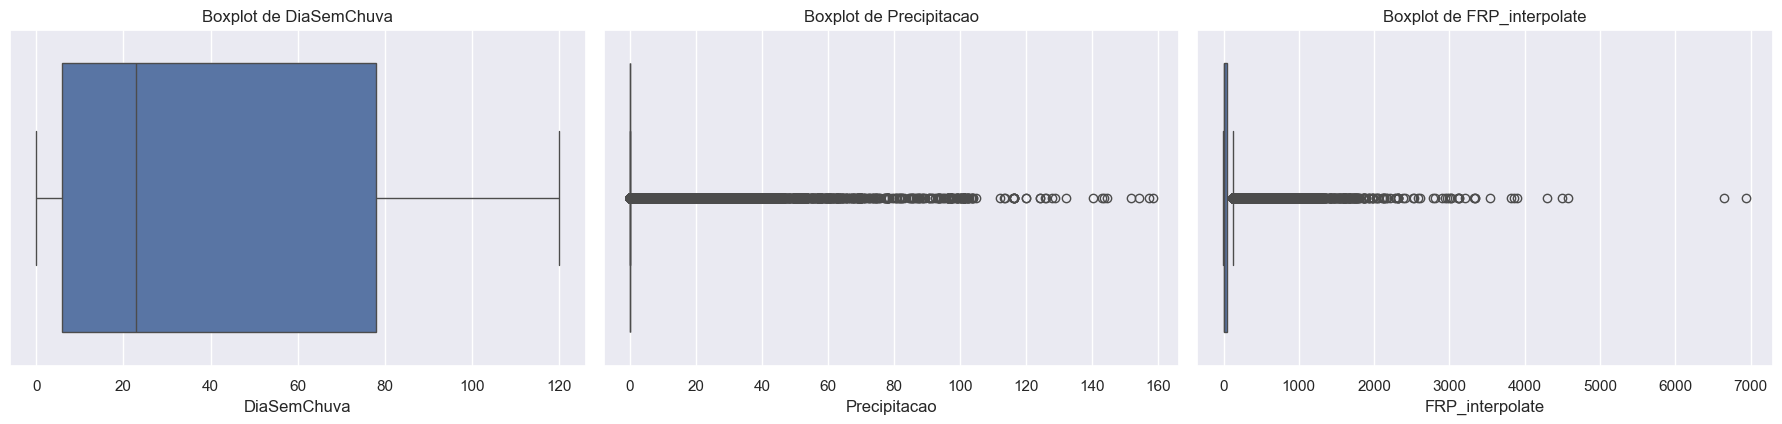

In [39]:
cols = ['DiaSemChuva', 'Precipitacao', 'FRP_interpolate']

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=amostra, x=col, ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')
    
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [40]:
# limitando outliers
frp_limite = amostra['FRP_interpolate'].quantile(0.99) 
amostra['FRP_tratado'] = amostra['FRP_interpolate'].clip(upper=frp_limite)

<Axes: xlabel='FRP_tratado', ylabel='Count'>

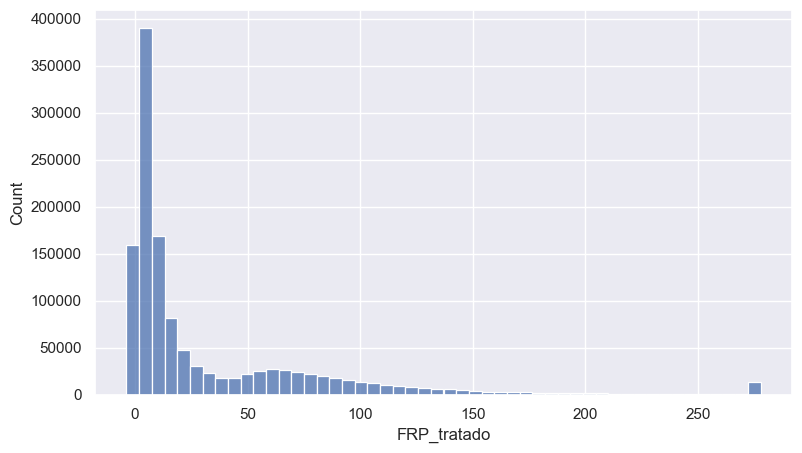

In [41]:
sns.histplot(amostra['FRP_tratado'], bins=50)

In [42]:
amostra = amostra[amostra['FRP_tratado'] >= 0]
amostra['FRP_log'] = np.log1p(amostra['FRP_tratado'])

In [43]:
amostra.isnull().sum()

Bioma                  0
DiaSemChuva            0
Precipitacao           0
RiscoFogo              0
Latitude               0
Longitude              0
FRP                55554
Região                 0
FRP_interpolate        0
FRP_tratado            0
FRP_log                0
dtype: int64

In [44]:
amostra = amostra.reset_index()

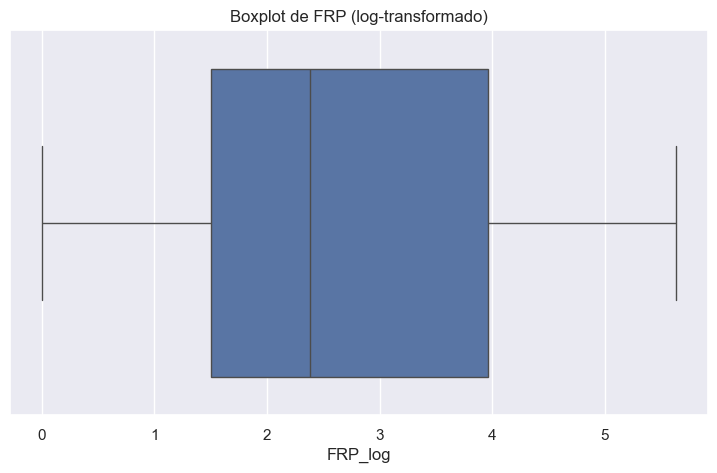

In [45]:
sns.boxplot(x=amostra['FRP_log'], data=amostra)
plt.title('Boxplot de FRP (log-transformado)')
plt.show()

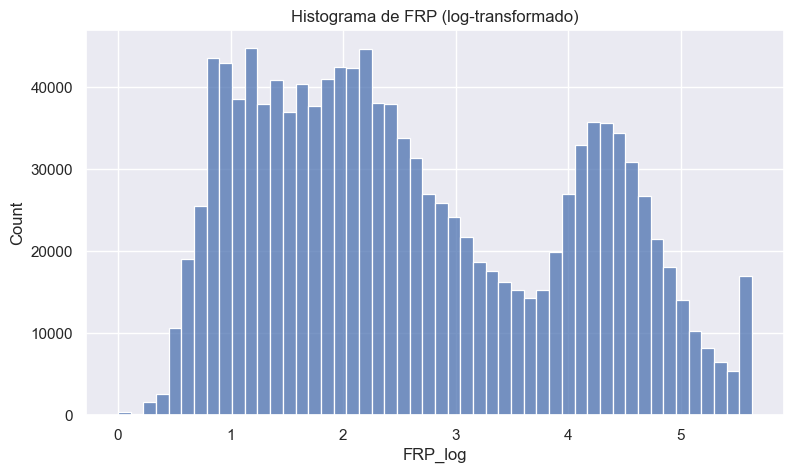

In [46]:
sns.histplot(amostra['FRP_log'], bins=50)
plt.title('Histograma de FRP (log-transformado)')
plt.show()

In [47]:
# limitando outliers
prec_limite = amostra['Precipitacao'].quantile(0.99) 
amostra['Precipitacao_tratado'] = amostra['Precipitacao'].clip(upper=prec_limite)

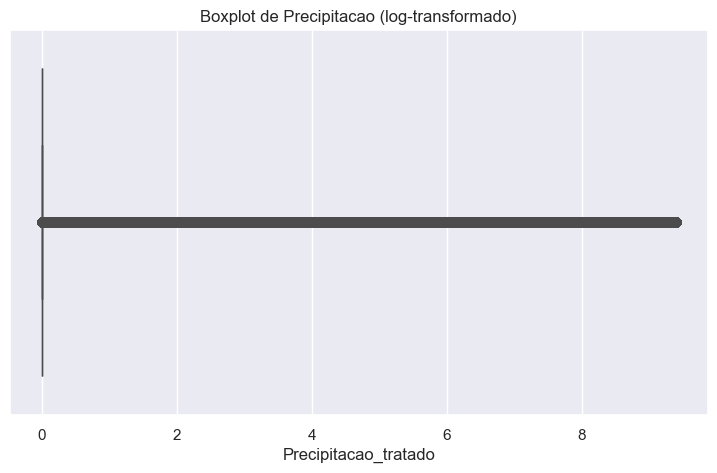

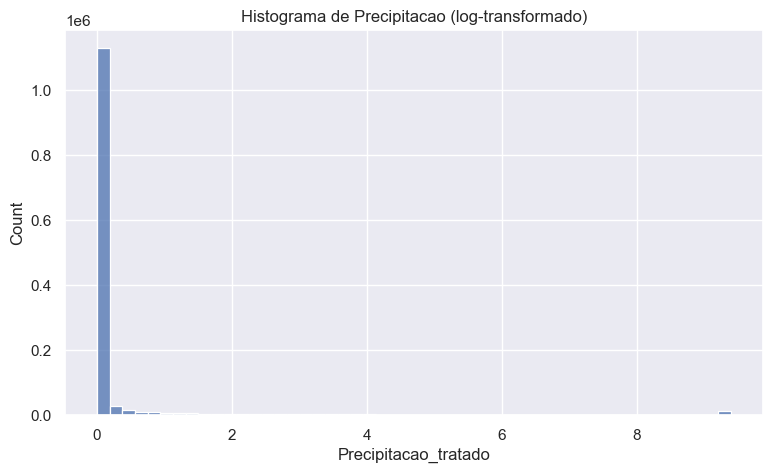

In [48]:
sns.boxplot(x='Precipitacao_tratado', data=amostra)
plt.title('Boxplot de Precipitacao (log-transformado)')
plt.show()

sns.histplot(amostra['Precipitacao_tratado'], bins=50)
plt.title('Histograma de Precipitacao (log-transformado)')
plt.show()

In [49]:
amostra['Precipitacao_log'] = np.log1p(amostra['Precipitacao_tratado'])

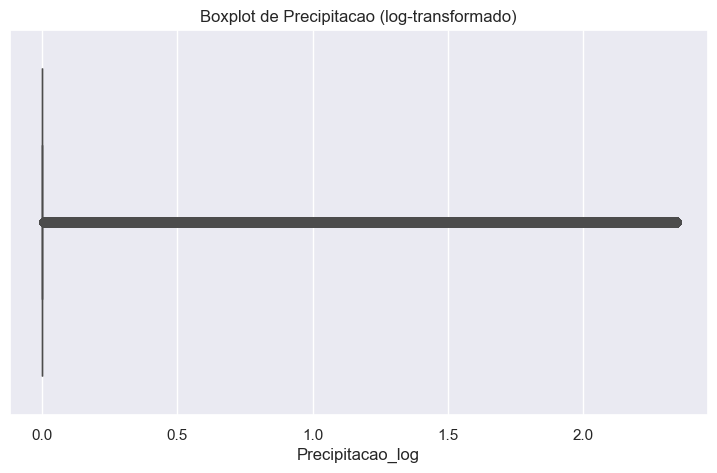

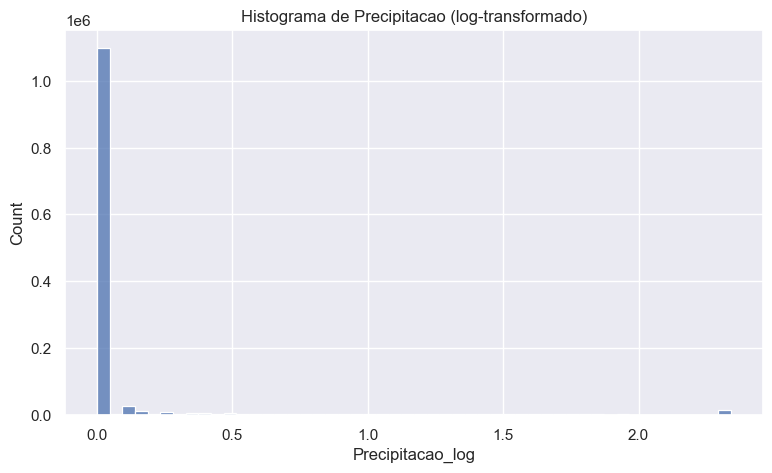

In [50]:
sns.boxplot(x='Precipitacao_log', data=amostra)
plt.title('Boxplot de Precipitacao (log-transformado)')
plt.show()

sns.histplot(amostra['Precipitacao_log'], bins=50)
plt.title('Histograma de Precipitacao (log-transformado)')
plt.show()

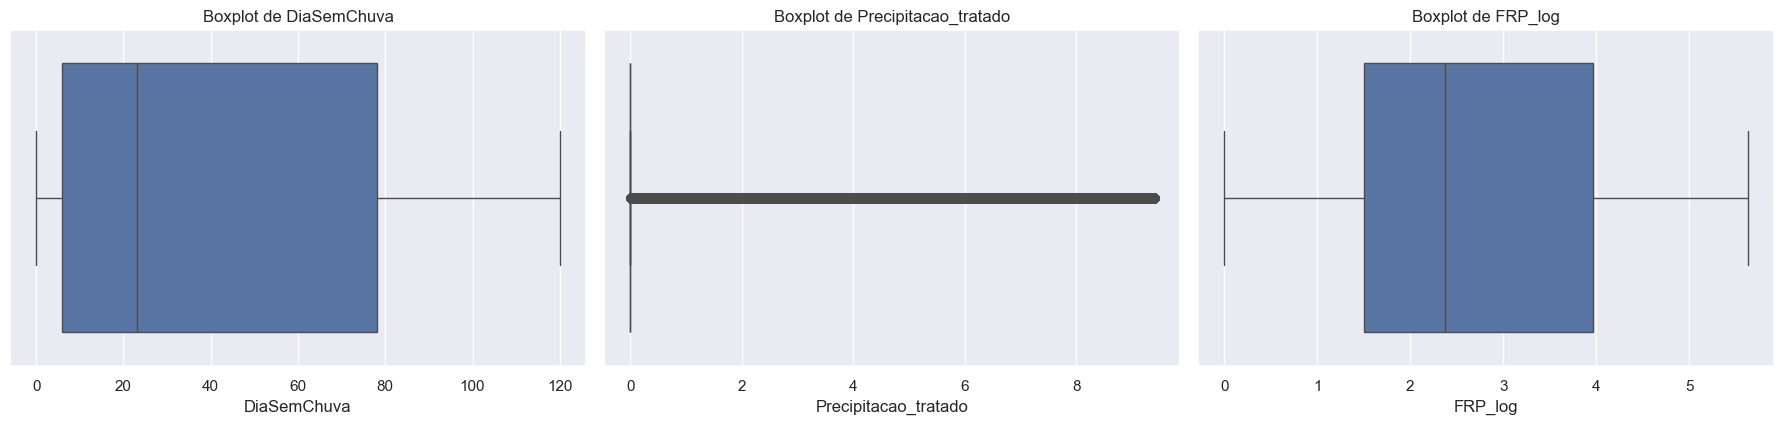

In [51]:
cols = ['DiaSemChuva', 'Precipitacao_tratado', 'FRP_log']

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=amostra, x=col, ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')
    
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### One hot encoding das variáveis

In [52]:
bioma_dummies = pd.get_dummies(amostra['Bioma'], prefix='Bioma', drop_first=True).astype(int)
regiao_dummies = pd.get_dummies(amostra['Região'], prefix='Região', drop_first=True).astype(int)

amostra = pd.concat([amostra, bioma_dummies, regiao_dummies], axis=1)

In [53]:
amostra.columns

Index(['DataHora', 'Bioma', 'DiaSemChuva', 'Precipitacao', 'RiscoFogo',
       'Latitude', 'Longitude', 'FRP', 'Região', 'FRP_interpolate',
       'FRP_tratado', 'FRP_log', 'Precipitacao_tratado', 'Precipitacao_log',
       'Bioma_Caatinga', 'Bioma_Cerrado', 'Bioma_Mata Atlântica',
       'Bioma_Pampa', 'Bioma_Pantanal', 'Região_NORDESTE', 'Região_NORTE',
       'Região_SUDESTE', 'Região_SUL'],
      dtype='object')

In [54]:
amostra.head()

,DataHora,Bioma,DiaSemChuva,Precipitacao,RiscoFogo,Latitude,Longitude,FRP,Região,FRP_interpolate,...,Precipitacao_log,Bioma_Caatinga,Bioma_Cerrado,Bioma_Mata Atlântica,Bioma_Pampa,Bioma_Pantanal,Região_NORDESTE,Região_NORTE,Região_SUDESTE,Região_SUL
0,2024-08-01 00:03:16,Mata Atlântica,2.0,0.0,1.00,-22.6800,-51.4500,NaN,SUL,65.1,...,0.0,0,0,1,0,0,0,0,0,1
1,2024-08-01 00:04:51,Amazônia,22.0,0.0,0.59,-6.4000,-56.4000,NaN,NORTE,65.1,...,0.0,0,0,0,0,0,0,1,0,0
2,2024-08-01 00:05:20,Amazônia,21.0,0.0,0.20,-2.4631,-49.3789,65.1,NORTE,65.1,...,0.0,0,0,0,0,0,0,1,0,0
3,2024-08-01 00:05:30,Amazônia,21.0,0.0,0.82,-4.1801,-46.6106,97.7,NORDESTE,97.7,...,0.0,0,0,0,0,0,1,0,0,0
4,2024-08-01 00:05:38,Cerrado,24.0,0.0,0.81,-5.5858,-43.2562,49.8,NORDESTE,49.8,...,0.0,0,1,0,0,0,1,0,0,0


In [55]:
amostra = amostra.drop(columns=['Bioma', 'Região'])

### Tratando variável latitude de longitude

In [56]:
# conversao para radianos 
lat_rad = np.radians(amostra['Latitude'])
lon_rad = np.radians(amostra['Longitude'])

In [57]:
# Transformando em coordenadas 3D na esfera
amostra['x_coord'] = np.cos(lat_rad) * np.cos(lon_rad)
amostra['y_coord'] = np.cos(lat_rad) * np.sin(lon_rad)
amostra['z_coord'] = np.sin(lat_rad)

In [58]:
amostra.head()

,DataHora,DiaSemChuva,Precipitacao,RiscoFogo,Latitude,Longitude,FRP,FRP_interpolate,FRP_tratado,FRP_log,...,Bioma_Mata Atlântica,Bioma_Pampa,Bioma_Pantanal,Região_NORDESTE,Região_NORTE,Região_SUDESTE,Região_SUL,x_coord,y_coord,z_coord
0,2024-08-01 00:03:16,2.0,0.0,1.00,-22.6800,-51.4500,NaN,65.1,65.1,4.191169,...,1,0,0,0,0,0,1,0.575007,-0.721590,-0.385584
1,2024-08-01 00:04:51,22.0,0.0,0.59,-6.4000,-56.4000,NaN,65.1,65.1,4.191169,...,0,0,0,0,1,0,0,0.549943,-0.827730,-0.111469
2,2024-08-01 00:05:20,21.0,0.0,0.20,-2.4631,-49.3789,65.1,65.1,65.1,4.191169,...,0,0,0,0,1,0,0,0.650452,-0.758330,-0.042976
3,2024-08-01 00:05:30,21.0,0.0,0.82,-4.1801,-46.6106,97.7,97.7,97.7,4.592085,...,0,0,0,1,0,0,0,0.685126,-0.724769,-0.072892
4,2024-08-01 00:05:38,24.0,0.0,0.81,-5.5858,-43.2562,49.8,49.8,49.8,3.927896,...,0,0,0,1,0,0,0,0.724839,-0.682008,-0.097336


In [59]:
amostra.columns

Index(['DataHora', 'DiaSemChuva', 'Precipitacao', 'RiscoFogo', 'Latitude',
       'Longitude', 'FRP', 'FRP_interpolate', 'FRP_tratado', 'FRP_log',
       'Precipitacao_tratado', 'Precipitacao_log', 'Bioma_Caatinga',
       'Bioma_Cerrado', 'Bioma_Mata Atlântica', 'Bioma_Pampa',
       'Bioma_Pantanal', 'Região_NORDESTE', 'Região_NORTE', 'Região_SUDESTE',
       'Região_SUL', 'x_coord', 'y_coord', 'z_coord'],
      dtype='object')

In [60]:
cols = ['FRP', 'FRP_interpolate', 'FRP_tratado', 'Precipitacao_log', 'Latitude', 'Longitude']
amostra = amostra.drop(columns=cols, axis=1)

### Arquitetura 1 - Prophet

In [61]:
amostra = amostra.reset_index()

In [57]:
amostra.columns

Index(['index', 'DataHora', 'DiaSemChuva', 'Precipitacao', 'RiscoFogo',
       'Latitude', 'Longitude', 'FRP', 'FRP_interpolate', 'FRP_tratado',
       'FRP_log', 'Precipitacao_tratado', 'Precipitacao_log', 'Bioma_Caatinga',
       'Bioma_Cerrado', 'Bioma_Mata Atlântica', 'Bioma_Pampa',
       'Bioma_Pantanal', 'Região_NORDESTE', 'Região_NORTE', 'Região_SUDESTE',
       'Região_SUL'],
      dtype='object')

In [70]:
colunas_norm = ['DiaSemChuva', 'RiscoFogo', 'Precipitacao_tratado']

colunas = ['Bioma_Caatinga', 'Bioma_Cerrado', 'Bioma_Mata Atlântica', 'Bioma_Pampa', 'Bioma_Pantanal', 
                       'Região_NORDESTE', 'Região_NORTE', 'Região_SUDESTE', 'Região_SUL', 'x_coord', 'y_coord', 'z_coord']

In [71]:
scaler = MinMaxScaler()
df_numericas_norm = pd.DataFrame(
    scaler.fit_transform(amostra[colunas_norm]),
    columns=colunas_norm,
    index=amostra.index
)

In [72]:
df_final = pd.concat([amostra[['DataHora', 'FRP_log']], df_numericas_norm, amostra[colunas]], axis=1)
df_final.columns = ['ds', 'y'] + colunas_norm + colunas

split_idx = int(len(df_final) * 0.8)
train = df_final.iloc[:split_idx]
test = df_final.iloc[split_idx:]

model = Prophet()
for reg in colunas_norm + colunas:
    model.add_regressor(reg)

model.fit(train)

future = test[['ds'] + colunas_norm + colunas]
forecast = model.predict(future)

y_true = test['y'].values
y_pred = forecast['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"\nAvaliação no conjunto de teste:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² : {r2:.3f}")

15:51:32 - cmdstanpy - INFO - Chain [1] start processing
16:02:14 - cmdstanpy - INFO - Chain [1] done processing



Avaliação no conjunto de teste:
MAE: 0.66
MSE: 0.76
R² : 0.585


### Arquitetura 2 - MLP PURO

In [73]:
numericas = ['DiaSemChuva', 'RiscoFogo', 'Precipitacao_tratado']
others = ['Bioma_Caatinga', 'Bioma_Cerrado', 'Bioma_Mata Atlântica', 'Bioma_Pampa', 'Bioma_Pantanal', 
        'Região_NORDESTE', 'Região_NORTE', 'Região_SUDESTE', 'Região_SUL', 'x_coord', 'y_coord', 'z_coord']

scaler = MinMaxScaler()
numericas_norm = pd.DataFrame(scaler.fit_transform(amostra[numericas]), columns=numericas)

df_dummies = amostra[others]
target = amostra[['FRP_log']]

df_novo = pd.concat([numericas_norm, df_dummies, target], axis=1)


x = df_novo.drop('FRP_log', axis=1).values
y = df_novo['FRP_log'].values

In [74]:
amostra['FRP_log'].isna().sum()

0

In [75]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
resultados = []

for fold, (train_idx, test_idx) in enumerate(kf.split(x)):
    print(f"\nFOLD {fold+1}")
    X_train, X_test = x[train_idx], x[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')

    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.3f} | MSE: {mse:.3f} | R²: {r2:.3f}")
    resultados.append((mae, mse, r2))

maes, mses, r2s = zip(*resultados)
print("\nMÉDIA DOS FOLDS:")
print(f"MAE médio: {np.mean(maes):.3f}")
print(f"MSE médio: {np.mean(mses):.3f}")
print(f"R² médio: {np.mean(r2s):.3f}")



FOLD 1
Treino: (850895, 15) | Teste: (425448, 15)


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 29s 1ms/step - loss: 1.9283
Epoch 2/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 30s 1ms/step - loss: 1.8634
Epoch 3/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step - loss: 1.8580
Epoch 4/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 29s 1ms/step - loss: 1.8559
Epoch 5/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 26s 975us/step - loss: 1.8549
Epoch 6/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 26s 964us/step - loss: 1.8496
Epoch 7/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 26s 978us/step - loss: 1.8518
Epoch 8/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 26s 960us/step - loss: 1.8507
Epoch 9/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 26s 980us/step - loss: 1.8519
Epoch 10/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 26s 962us/step - loss: 1.8470
13296/13296 ━━━━━━━━━━━━━━━━━━━━ 7s 540us/step
MAE: 1.168 | MSE: 1.851 | R²: 0.022

FOLD 2
Treino: (850895, 15) | Teste: (425448, 15)
Epoch 1/10


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



26591/26591 ━━━━━━━━━━━━━━━━━━━━ 27s 973us/step - loss: 1.9100
Epoch 2/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 26s 971us/step - loss: 1.8622
Epoch 3/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 27s 998us/step - loss: 1.8567
Epoch 4/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 1.8575
Epoch 5/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 1.8548
Epoch 6/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - loss: 1.8577
Epoch 7/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 1.8589
Epoch 8/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 34s 1ms/step - loss: 1.8564
Epoch 9/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 1.8517
Epoch 10/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step - loss: 1.8496
13296/13296 ━━━━━━━━━━━━━━━━━━━━ 11s 786us/step
MAE: 1.176 | MSE: 1.854 | R²: 0.018

FOLD 3
Treino: (850896, 15) | Teste: (425447, 15)
Epoch 1/10


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



26591/26591 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 1.9167
Epoch 2/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 34s 1ms/step - loss: 1.8641
Epoch 3/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step - loss: 1.8633
Epoch 4/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step - loss: 1.8593
Epoch 5/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step - loss: 1.8591
Epoch 6/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 1.8562
Epoch 7/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 34s 1ms/step - loss: 1.8564
Epoch 8/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 1.8535
Epoch 9/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 1.8556
Epoch 10/10
26591/26591 ━━━━━━━━━━━━━━━━━━━━ 34s 1ms/step - loss: 1.8507
13296/13296 ━━━━━━━━━━━━━━━━━━━━ 12s 887us/step
MAE: 1.163 | MSE: 1.845 | R²: 0.024

MÉDIA DOS FOLDS:
MAE médio: 1.169
MSE médio: 1.850
R² médio: 0.022


#### Arquitetura 3 - MLP + Uso das variáveis temporais + Early Stopping

In [65]:
amostra['hora'] = amostra['DataHora'].dt.hour
amostra['dia'] = amostra['DataHora'].dt.day
amostra['mes'] = amostra['DataHora'].dt.month
amostra['dia_semana'] = amostra['DataHora'].dt.dayofweek

In [66]:
amostra['hora_sin'] = np.sin(2 * np.pi * amostra['hora'] / 24)
amostra['hora_cos'] = np.cos(2 * np.pi * amostra['hora'] / 24)
amostra['mes_sin'] = np.sin(2 * np.pi * amostra['mes'] / 12)
amostra['mes_cos'] = np.cos(2 * np.pi * amostra['mes'] / 12)
amostra['dia_semana_sin'] = np.sin(2 * np.pi * amostra['dia_semana'] / 7)
amostra['dia_semana_cos'] = np.cos(2 * np.pi * amostra['dia_semana'] / 7)

In [64]:
amostra.head()

,DataHora,DiaSemChuva,Precipitacao,RiscoFogo,FRP_log,Precipitacao_tratado,Bioma_Caatinga,Bioma_Cerrado,Bioma_Mata Atlântica,Bioma_Pampa,...,hora,dia,mes,dia_semana,hora_sin,hora_cos,mes_sin,mes_cos,dia_semana_sin,dia_semana_cos
0,2024-08-01 00:03:16,2.0,0.0,1.00,4.191169,0.0,0,0,1,0,...,0,1,8,3,0.0,1.0,-0.866025,-0.5,0.433884,-0.900969
1,2024-08-01 00:04:51,22.0,0.0,0.59,4.191169,0.0,0,0,0,0,...,0,1,8,3,0.0,1.0,-0.866025,-0.5,0.433884,-0.900969
2,2024-08-01 00:05:20,21.0,0.0,0.20,4.191169,0.0,0,0,0,0,...,0,1,8,3,0.0,1.0,-0.866025,-0.5,0.433884,-0.900969
3,2024-08-01 00:05:30,21.0,0.0,0.82,4.592085,0.0,0,0,0,0,...,0,1,8,3,0.0,1.0,-0.866025,-0.5,0.433884,-0.900969
4,2024-08-01 00:05:38,24.0,0.0,0.81,3.927896,0.0,0,1,0,0,...,0,1,8,3,0.0,1.0,-0.866025,-0.5,0.433884,-0.900969


In [60]:
colunas_norm = ['DiaSemChuva','RiscoFogo', 'Precipitacao_tratado']

colunas_extras = ['hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos',
    'Bioma_Caatinga', 'Bioma_Cerrado', 'Bioma_Mata Atlântica', 'Bioma_Pampa', 'Bioma_Pantanal',
    'Região_NORDESTE', 'Região_NORTE', 'Região_SUDESTE', 'Região_SUL', 'x_coord', 'y_coord', 'z_coord'
]

features = colunas_norm + colunas_extras

In [ ]:
X = amostra[features].copy()
y = amostra['FRP_log'].copy()

scaler = MinMaxScaler()
X[colunas_norm] = scaler.fit_transform(X[colunas_norm])

X = X.values
y = y.values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"\nFOLD {fold+1}")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')

    early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=20, validation_split=0.3,  callbacks=[early_stopping])

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.3f} | MSE: {mse:.3f} | R²: {r2:.3f}")
    resultados.append((mae, mse, r2))

maes, mses, r2s = zip(*resultados)
print("\nMÉDIA DOS FOLDS:")
print(f"MAE médio: {np.mean(maes):.3f}")
print(f"MSE médio: {np.mean(mses):.3f}")
print(f"R² médio: {np.mean(r2s):.3f}")



FOLD 1
Treino: (1021074, 21) | Teste: (255269, 21)
Epoch 1/20


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



22336/22336 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.9326 - val_loss: 0.7803
Epoch 2/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - loss: 0.7605 - val_loss: 0.7563
Epoch 3/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step - loss: 0.7517 - val_loss: 0.7614
Epoch 4/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 29s 1ms/step - loss: 0.7449 - val_loss: 0.7467
Epoch 5/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 28s 1ms/step - loss: 0.7411 - val_loss: 0.7512
Epoch 6/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 0.7383 - val_loss: 0.8013
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 4s 531us/step
MAE: 0.651 | MSE: 0.746 | R²: 0.607

FOLD 2
Treino: (1021074, 21) | Teste: (255269, 21)
Epoch 1/20


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



22336/22336 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step - loss: 0.8955 - val_loss: 0.7086
Epoch 2/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.7555 - val_loss: 0.7293
Epoch 3/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 0.7469 - val_loss: 0.7552
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 6s 718us/step
MAE: 0.640 | MSE: 0.743 | R²: 0.607

FOLD 3
Treino: (1021074, 21) | Teste: (255269, 21)
Epoch 1/20


...

22336/22336 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - loss: 0.9091 - val_loss: 0.7649
Epoch 2/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step - loss: 0.7555 - val_loss: 0.7209
Epoch 3/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 0.7485 - val_loss: 0.7360
Epoch 4/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step - loss: 0.7431 - val_loss: 0.7234
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 7s 857us/step
MAE: 0.633 | MSE: 0.741 | R²: 0.608

FOLD 4
Treino: (1021075, 21) | Teste: (255268, 21)


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 0.9493 - val_loss: 0.7217
Epoch 2/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step - loss: 0.7604 - val_loss: 0.7071
Epoch 3/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 0.7542 - val_loss: 0.7234
Epoch 4/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step - loss: 0.7453 - val_loss: 0.7414
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 5s 638us/step
MAE: 0.635 | MSE: 0.735 | R²: 0.611

FOLD 5
Treino: (1021075, 21) | Teste: (255268, 21)
Epoch 1/20


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



22336/22336 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 0.8907 - val_loss: 0.7247
Epoch 2/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 0.7586 - val_loss: 0.7289
Epoch 3/20
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 0.7468 - val_loss: 0.7814
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 5s 610us/step
MAE: 0.649 | MSE: 0.758 | R²: 0.599

MÉDIA DOS FOLDS:
MAE médio: 0.642
MSE médio: 0.744
R² médio: 0.606


#### Arquitetura 4 - MLP + Uso das variáveis temporais + Early Stopping + Ajustes nos hiperparâmetros + L2 + Batch Normalization e Dropout

In [63]:
from tensorflow.keras.regularizers import l2

In [113]:
X = amostra[features].copy()
y = amostra['FRP_log'].copy()

scaler = MinMaxScaler()
X[colunas_norm] = scaler.fit_transform(X[colunas_norm])

X = X.values
y = y.values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"\nFOLD {fold+1}")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    model.fit(X_train, y_train, epochs=10, validation_split=0.3, callbacks=[early_stop], batch_size=32)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.3f} | MSE: {mse:.3f} | R²: {r2:.3f}")
    resultados.append((mae, mse, r2))

# Estatísticas
maes, mses, r2s = zip(*resultados)
print("\nMÉDIA DOS FOLDS:")
print(f"MAE médio: {np.mean(maes):.3f}")
print(f"MSE médio: {np.mean(mses):.3f}")
print(f"R² médio: {np.mean(r2s):.3f}")



FOLD 1
Treino: (1021074, 21) | Teste: (255269, 21)


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 49s 2ms/step - loss: 1.1818 - val_loss: 0.8390
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - loss: 0.8454 - val_loss: 0.7662
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 0.8422 - val_loss: 0.7459
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 0.8365 - val_loss: 0.7581
Epoch 5/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.8346 - val_loss: 0.7717
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 5s 605us/step
MAE: 0.682 | MSE: 0.766 | R²: 0.596

FOLD 2
Treino: (1021074, 21) | Teste: (255269, 21)


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 1.1747 - val_loss: 0.7573
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - loss: 0.8494 - val_loss: 0.7214
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.8435 - val_loss: 0.7416
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.8399 - val_loss: 0.7554
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 5s 570us/step
MAE: 0.652 | MSE: 0.746 | R²: 0.606

FOLD 3
Treino: (1021074, 21) | Teste: (255269, 21)
Epoch 1/10


...

22336/22336 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 1.1827 - val_loss: 0.7266
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.8533 - val_loss: 0.7350
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - loss: 0.8458 - val_loss: 0.7066
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.8384 - val_loss: 0.7287
Epoch 5/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.8375 - val_loss: 0.7495
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 5s 579us/step
MAE: 0.648 | MSE: 0.743 | R²: 0.607

FOLD 4
Treino: (1021075, 21) | Teste: (255268, 21)
Epoch 1/10


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



22336/22336 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 1.1735 - val_loss: 0.7948
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - loss: 0.8491 - val_loss: 0.7412
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 0.8387 - val_loss: 0.7689
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 0.8372 - val_loss: 0.7415
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 5s 583us/step
MAE: 0.655 | MSE: 0.750 | R²: 0.603

FOLD 5
Treino: (1021075, 21) | Teste: (255268, 21)


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - loss: 1.1622 - val_loss: 0.7726
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.8436 - val_loss: 0.7325
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 0.8411 - val_loss: 0.7688
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step - loss: 0.8365 - val_loss: 0.7347
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 5s 570us/step
MAE: 0.645 | MSE: 0.758 | R²: 0.599

MÉDIA DOS FOLDS:
MAE médio: 0.656
MSE médio: 0.753
R² médio: 0.602


#### Arquitetura 4 - MLP + Uso das variáveis temporais + Early Stopping + Ajustes do número de neurônios e camadas + L2 + Remoção variáves categóricas (REGIÃO E BIOMA) + Ajustes no dropout

In [59]:
colunas_norm = ['DiaSemChuva', 'Precipitacao', 'RiscoFogo', 'Precipitacao_tratado', 'FRP_log']

colunas_extras = ['hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos',
    'Bioma_Caatinga', 'Bioma_Cerrado', 'Bioma_Mata Atlântica', 'Bioma_Pampa', 'Bioma_Pantanal',
    'Região_NORDESTE', 'Região_NORTE', 'Região_SUDESTE', 'Região_SUL', 'x_coord', 'y_coord', 'z_coord'
]

features = colunas_norm + colunas_extras

<Axes: >

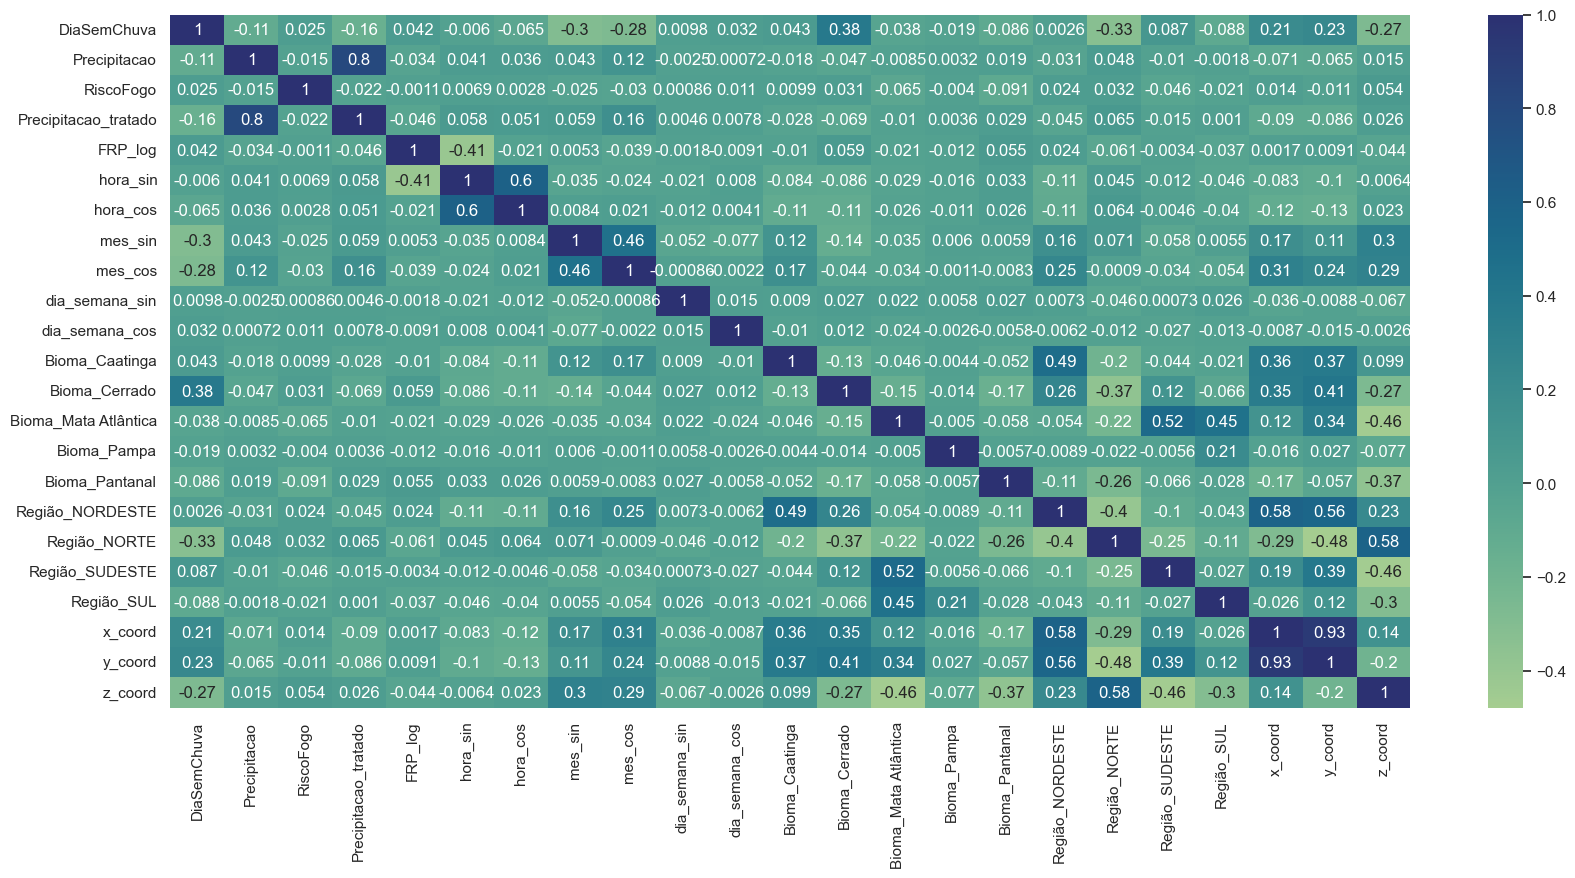

In [ ]:
plt.figure(figsize=(20,9))
sns.heatmap(amostra[features].corr(), cmap="crest", annot=True)

<Axes: >

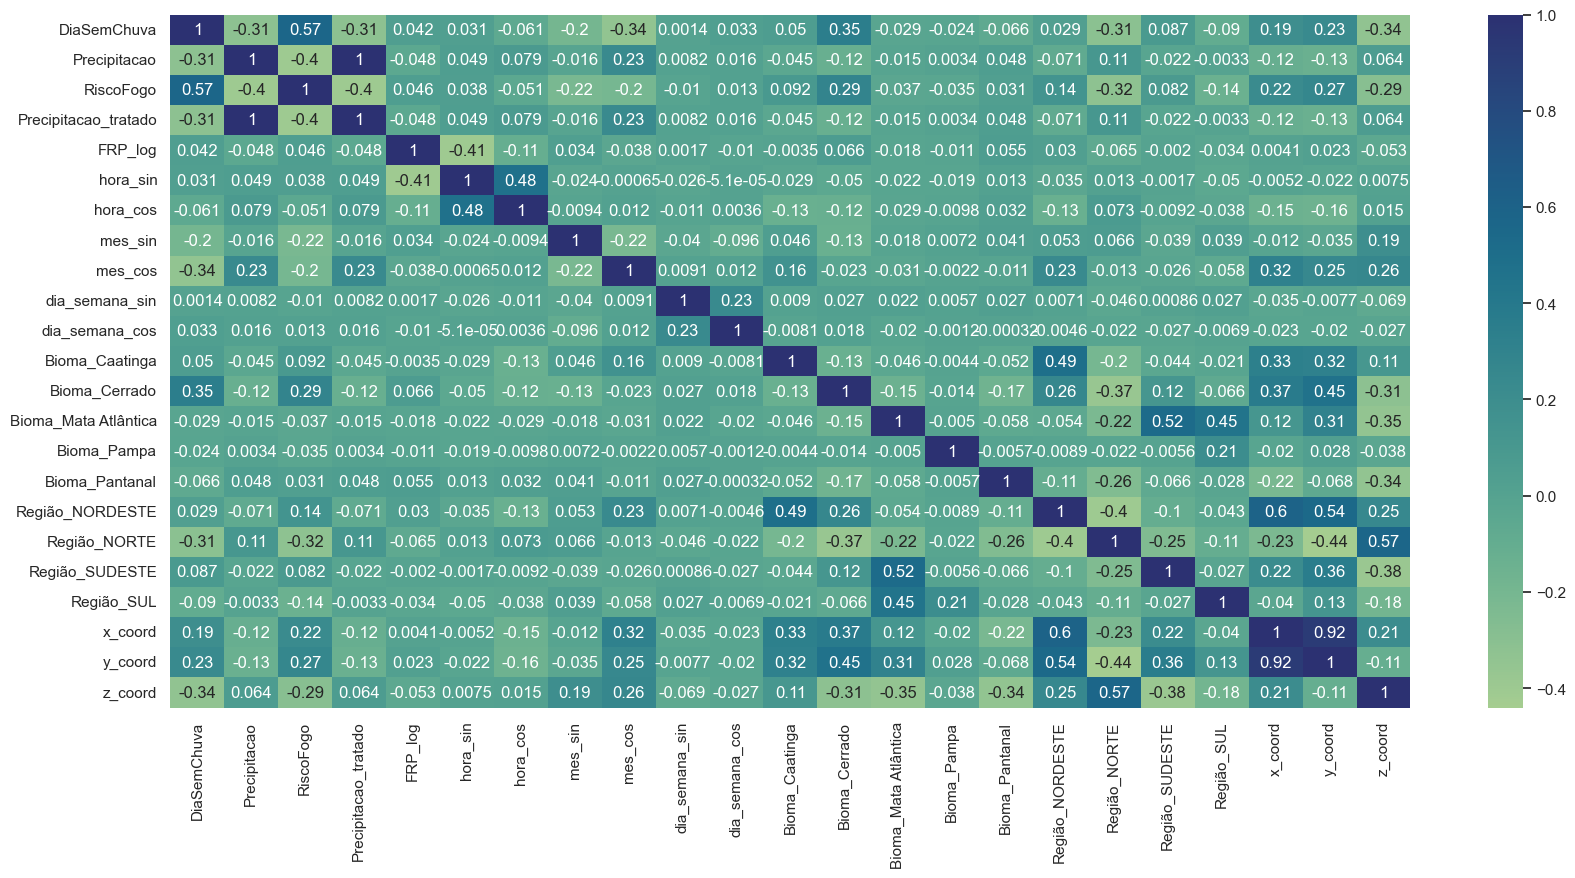

In [66]:
plt.figure(figsize=(20,9))
sns.heatmap(amostra[features].corr(method='spearman'), cmap="crest", annot=True)

In [ ]:
# ajustes com variaveis categoricas 
kf = KFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"\nFOLD {fold+1}")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1)) 

    model.compile(optimizer='adam', loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    model.fit(X_train, y_train, epochs=10, validation_split=0.3, callbacks=[early_stop])

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.3f} | MSE: {mse:.3f} | R²: {r2:.3f}")
    resultados.append((mae, mse, r2))

# Estatísticas
maes, mses, r2s = zip(*resultados)
print("\nMÉDIA DOS FOLDS:")
print(f"MAE médio: {np.mean(maes):.3f}")
print(f"MSE médio: {np.mean(mses):.3f}")
print(f"R² médio: {np.mean(r2s):.3f}")


FOLD 1
Treino: (1021074, 21) | Teste: (255269, 21)


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.9507 - val_loss: 0.7180
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 0.7881 - val_loss: 0.7135
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.7791 - val_loss: 0.7256
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - loss: 0.7789 - val_loss: 0.7186
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 6s 758us/step
MAE: 0.634 | MSE: 0.741 | R²: 0.609

FOLD 2
Treino: (1021074, 21) | Teste: (255269, 21)


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 0.9278 - val_loss: 0.7227
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - loss: 0.7892 - val_loss: 0.7058
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 0.7836 - val_loss: 0.7003
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 0.7794 - val_loss: 0.6948
Epoch 5/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.7775 - val_loss: 0.7083
Epoch 6/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 0.7792 - val_loss: 0.7109
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
MAE: 0.633 | MSE: 0.733 | R²: 0.613

FOLD 3
Treino: (1021074, 21) | Teste: (255269, 21)
Epoch 1/10


...

22336/22336 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - loss: 0.9421 - val_loss: 0.7526
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.7925 - val_loss: 0.7135
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 0.7855 - val_loss: 0.7122
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 0.7820 - val_loss: 0.7148
Epoch 5/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 0.7806 - val_loss: 0.7114
Epoch 6/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - loss: 0.7822 - val_loss: 0.7051
Epoch 7/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - loss: 0.7784 - val_loss: 0.7145
Epoch 8/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.7780 - val_loss: 0.7117
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 6s 714us/step
MAE: 0.635 | MSE: 0.726 | R²: 0.616

FOLD 4
Treino: (1021075, 21) | Teste: (255268, 21)


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - loss: 0.9247 - val_loss: 0.7184
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 47s 2ms/step - loss: 0.7885 - val_loss: 0.7163
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 0.7869 - val_loss: 0.7100
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 0.7825 - val_loss: 0.6991
Epoch 5/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - loss: 0.7824 - val_loss: 0.7254
Epoch 6/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.7811 - val_loss: 0.7000
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 7s 805us/step
MAE: 0.639 | MSE: 0.730 | R²: 0.613

FOLD 5
Treino: (1021075, 21) | Teste: (255268, 21)


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 34s 1ms/step - loss: 0.9204 - val_loss: 0.7095
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 31s 1ms/step - loss: 0.7887 - val_loss: 0.7192
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step - loss: 0.7803 - val_loss: 0.7082
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.7807 - val_loss: 0.6979
Epoch 5/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 0.7799 - val_loss: 0.6950
Epoch 6/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.7774 - val_loss: 0.7086
Epoch 7/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - loss: 0.7793 - val_loss: 0.7035
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 6s 742us/step
MAE: 0.634 | MSE: 0.731 | R²: 0.613

MÉDIA DOS FOLDS:
MAE médio: 0.635
MSE médio: 0.732
R² médio: 0.613


In [95]:
colunas2 = ['DiaSemChuva', 'RiscoFogo', 'Precipitacao_tratado']

colunas_extras2 = ['hora_sin', 'hora_cos','mes_sin', 'mes_cos', 'dia_semana_sin', 
                   'dia_semana_cos', 'x_coord', 'y_coord', 'z_coord']

features2 = colunas2 + colunas_extras2

In [96]:
X = amostra[features2].copy()
y = amostra['FRP_log'].copy()

scaler = MinMaxScaler()
X[colunas2] = scaler.fit_transform(X[colunas2])

X = X.values
y = y.values

In [112]:
# COMPARATIVO: ajustes sem variaveis categoricas 

kf = KFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"\nFOLD {fold+1}")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.1))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1)) 

    model.compile(optimizer='adam', loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    model.fit(X_train, y_train, epochs=10, validation_split=0.3, callbacks=[early_stop], batch_size=64)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.3f} | MSE: {mse:.3f} | R²: {r2:.3f}")
    resultados.append((mae, mse, r2))

# Estatísticas
maes, mses, r2s = zip(*resultados)
print("\nMÉDIA DOS FOLDS:")
print(f"MAE médio: {np.mean(maes):.3f}")
print(f"MSE médio: {np.mean(mses):.3f}")
print(f"R² médio: {np.mean(r2s):.3f}")


FOLD 1
Treino: (1021074, 12) | Teste: (255269, 12)
Epoch 1/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 1.0262 - val_loss: 0.7504
Epoch 2/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 0.8297 - val_loss: 0.7265
Epoch 3/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 0.8068 - val_loss: 0.7238
Epoch 4/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 0.7993 - val_loss: 0.7218
Epoch 5/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.7959 - val_loss: 0.7437
Epoch 6/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.7921 - val_loss: 0.7150
Epoch 7/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 0.7919 - val_loss: 0.6954
Epoch 8/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 0.7888 - val_loss: 0.7094
Epoch 9/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 0.7901 - val_loss: 0.7158
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 7s 819us/step
MAE: 0.637 | MSE: 0.736 | R²: 0.612

FOLD 2
Treino: (1021074, 12) | Teste: (255269, 

/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



11168/11168 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 1.0365 - val_loss: 0.7471
Epoch 2/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.8243 - val_loss: 0.7276
Epoch 3/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 0.8027 - val_loss: 0.7229
Epoch 4/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 0.7971 - val_loss: 0.7234
Epoch 5/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 0.7946 - val_loss: 0.7209
Epoch 6/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 0.7947 - val_loss: 0.7289
Epoch 7/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - loss: 0.7897 - val_loss: 0.7417
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 5s 682us/step
MAE: 0.648 | MSE: 0.739 | R²: 0.609

FOLD 3
Treino: (1021074, 12) | Teste: (255269, 12)


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 1.0599 - val_loss: 0.7405
Epoch 2/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.8240 - val_loss: 0.7435
Epoch 3/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 0.8056 - val_loss: 0.7654
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 5s 612us/step
MAE: 0.658 | MSE: 0.763 | R²: 0.596

FOLD 4
Treino: (1021075, 12) | Teste: (255268, 12)
Epoch 1/10


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



11168/11168 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 1.0279 - val_loss: 0.7723
Epoch 2/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.8226 - val_loss: 0.7150
Epoch 3/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.8062 - val_loss: 0.7142
Epoch 4/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.7999 - val_loss: 0.6991
Epoch 5/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.7965 - val_loss: 0.7149
Epoch 6/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.7920 - val_loss: 0.7012
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 6s 715us/step
MAE: 0.637 | MSE: 0.737 | R²: 0.609

FOLD 5
Treino: (1021075, 12) | Teste: (255268, 12)
Epoch 1/10


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



11168/11168 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 1.0338 - val_loss: 0.7528
Epoch 2/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.8265 - val_loss: 0.7471
Epoch 3/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.8080 - val_loss: 0.7351
Epoch 4/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.7976 - val_loss: 0.7259
Epoch 5/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - loss: 0.7958 - val_loss: 0.7098
Epoch 6/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.7947 - val_loss: 0.7108
Epoch 7/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.7904 - val_loss: 0.6976
Epoch 8/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - loss: 0.7934 - val_loss: 0.7122
Epoch 9/10
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.7909 - val_loss: 0.6986
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 6s 685us/step
MAE: 0.633 | MSE: 0.743 | R²: 0.607

MÉDIA DOS FOLDS:
MAE médio: 0.643
MSE médio: 0.743
R² médio: 0.607


In [62]:
colunas3 = ['DiaSemChuva', 'RiscoFogo', 'Precipitacao_tratado']

colunas_extras3 = ['hora_sin', 'hora_cos','mes_sin', 'mes_cos', 'dia_semana_sin', 
                   'dia_semana_cos', 'x_coord', 'y_coord', 'z_coord']

features3 = colunas3 + colunas_extras3

In [64]:
# COMPARATIVO: ajustes sem variaveis categoricas + batch default

X = amostra[features3].copy()
y = amostra['FRP_log'].copy()

scaler = MinMaxScaler()
X[colunas3] = scaler.fit_transform(X[colunas3])

X = X.values
y = y.values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"\nFOLD {fold+1}")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.1))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1)) 

    model.compile(optimizer='adam', loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    model.fit(X_train, y_train, epochs=10, validation_split=0.3, callbacks=[early_stop])

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.3f} | MSE: {mse:.3f} | R²: {r2:.3f}")
    resultados.append((mae, mse, r2))

# Estatísticas
maes, mses, r2s = zip(*resultados)
print("\nMÉDIA DOS FOLDS:")
print(f"MAE médio: {np.mean(maes):.3f}")
print(f"MSE médio: {np.mean(mses):.3f}")
print(f"R² médio: {np.mean(r2s):.3f}")


FOLD 1
Treino: (1021074, 12) | Teste: (255269, 12)


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.9713 - val_loss: 0.7727
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.8215 - val_loss: 0.7382
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.8084 - val_loss: 0.7145
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.8054 - val_loss: 0.7081
Epoch 5/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.7986 - val_loss: 0.7077
Epoch 6/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.8011 - val_loss: 0.7133
Epoch 7/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.7957 - val_loss: 0.7097
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 6s 719us/step
MAE: 0.637 | MSE: 0.740 | R²: 0.610

FOLD 2
Treino: (1021074, 12) | Teste: (255269, 12)
Epoch 1/10


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



22336/22336 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - loss: 0.9770 - val_loss: 0.7784
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.8219 - val_loss: 0.7419
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - loss: 0.8144 - val_loss: 0.7531
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.8037 - val_loss: 0.7397
Epoch 5/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.8023 - val_loss: 0.7139
Epoch 6/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.7989 - val_loss: 0.7081
Epoch 7/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 0.7997 - val_loss: 0.7015
Epoch 8/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.8001 - val_loss: 0.7093
Epoch 9/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 0.7960 - val_loss: 0.7041
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 4s 553us/step
MAE: 0.648 | MSE: 0.742 | R²: 0.608

FOLD 3
Treino: (1021074, 12) | Teste: (255269, 12)
Epoch 1/10


...

22336/22336 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.9828 - val_loss: 0.7409
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.8335 - val_loss: 0.7294
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 47s 2ms/step - loss: 0.8117 - val_loss: 0.7179
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - loss: 0.8055 - val_loss: 0.7135
Epoch 5/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.8034 - val_loss: 0.7103
Epoch 6/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 0.8035 - val_loss: 0.7114
Epoch 7/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.8036 - val_loss: 0.7153
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 5s 613us/step
MAE: 0.641 | MSE: 0.742 | R²: 0.607

FOLD 4
Treino: (1021075, 12) | Teste: (255268, 12)
Epoch 1/10


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



22336/22336 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.9829 - val_loss: 0.7138
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.8201 - val_loss: 0.7174
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.8060 - val_loss: 0.7026
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step - loss: 0.8022 - val_loss: 0.7189
Epoch 5/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 0.7998 - val_loss: 0.7057
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 6s 771us/step
MAE: 0.639 | MSE: 0.729 | R²: 0.614

FOLD 5
Treino: (1021075, 12) | Teste: (255268, 12)
Epoch 1/10


/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



22336/22336 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - loss: 0.9832 - val_loss: 0.7336
Epoch 2/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.8166 - val_loss: 0.7461
Epoch 3/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.8042 - val_loss: 0.7293
Epoch 4/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.8011 - val_loss: 0.7258
Epoch 5/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.8000 - val_loss: 0.7104
Epoch 6/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step - loss: 0.7981 - val_loss: 0.7117
Epoch 7/10
22336/22336 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 0.7951 - val_loss: 0.7166
7978/7978 ━━━━━━━━━━━━━━━━━━━━ 6s 731us/step
MAE: 0.640 | MSE: 0.742 | R²: 0.607

MÉDIA DOS FOLDS:
MAE médio: 0.641
MSE médio: 0.739
R² médio: 0.609


### Arquitetura 5 - TAB Net

In [1]:
from pytorch_tabnet.tab_model import TabNetRegressor

In [67]:
X = amostra[features3].copy()
y = amostra['FRP_log'].copy()

scaler = MinMaxScaler()
X[colunas3] = scaler.fit_transform(X[colunas3])

X = X.values
y = y.values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {'r2': [], 'mse': [], 'rmse': [], 'mae': []}

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    print(f"\nFold {fold}")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)

    model = TabNetRegressor(n_d=32, n_a=32, n_steps=5)

    model.fit(X_train=X_train, y_train=y_train, eval_set=[(X_val, y_val)],  eval_metric=['mse'], max_epochs=10, patience=2)

    preds = model.predict(X_val).squeeze()

    r2   = r2_score(y_val, preds)
    mse  = mean_squared_error(y_val, preds)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_val, preds)

    results['r2'].append(r2)
    results['mse'].append(mse)
    results['rmse'].append(rmse)
    results['mae'].append(mae)

    print(f"Fold {fold} | R²: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")



Fold 1


/opt/miniconda3/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning:

Device used : cpu



epoch 0  | loss: 0.91726 | val_0_mse: 0.84082 |  0:01:58s
epoch 1  | loss: 0.80425 | val_0_mse: 0.76049 |  0:03:55s
epoch 2  | loss: 0.75479 | val_0_mse: 0.7471  |  0:05:47s
epoch 3  | loss: 0.74825 | val_0_mse: 0.74959 |  0:07:41s
epoch 4  | loss: 0.7449  | val_0_mse: 0.73227 |  0:09:47s
epoch 5  | loss: 0.73776 | val_0_mse: 0.73497 |  0:12:03s
epoch 6  | loss: 0.73854 | val_0_mse: 0.7291  |  0:14:48s
epoch 7  | loss: 0.73152 | val_0_mse: 0.73228 |  0:17:05s
epoch 8  | loss: 0.73424 | val_0_mse: 0.72406 |  0:19:28s
epoch 9  | loss: 0.72629 | val_0_mse: 0.74944 |  0:22:01s
Stop training because you reached max_epochs = 10 with best_epoch = 8 and best_val_0_mse = 0.72406


/opt/miniconda3/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning:

Best weights from best epoch are automatically used!



Fold 1 | R²: 0.6181 | RMSE: 0.8509 | MAE: 0.6317

Fold 2


...

Fold 4 | R²: 0.6123 | RMSE: 0.8555 | MAE: 0.6395

Fold 5


/opt/miniconda3/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning:

Device used : cpu



epoch 0  | loss: 0.88997 | val_0_mse: 0.74926 |  0:02:03s
epoch 1  | loss: 0.75422 | val_0_mse: 0.74827 |  0:04:05s
epoch 2  | loss: 0.74336 | val_0_mse: 0.7397  |  0:06:03s
epoch 3  | loss: 0.73821 | val_0_mse: 0.73167 |  0:08:37s
epoch 4  | loss: 0.73243 | val_0_mse: 0.76693 |  0:12:00s
epoch 5  | loss: 0.73605 | val_0_mse: 0.72497 |  0:15:33s
epoch 6  | loss: 0.75301 | val_0_mse: 0.73434 |  0:19:07s
epoch 7  | loss: 0.73219 | val_0_mse: 0.72422 |  0:22:48s
epoch 8  | loss: 0.72701 | val_0_mse: 0.72071 |  0:25:39s
epoch 9  | loss: 0.72395 | val_0_mse: 0.73523 |  0:28:20s
Stop training because you reached max_epochs = 10 with best_epoch = 8 and best_val_0_mse = 0.72071


/opt/miniconda3/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning:

Best weights from best epoch are automatically used!



Fold 5 | R²: 0.6185 | RMSE: 0.8489 | MAE: 0.6286


In [68]:
print("Resultados médios dos 5 folds:")
for metric in results:
    mean_value = np.mean(results[metric])
    print(f"Média {metric.upper()}: {mean_value:.4f}")

Resultados médios dos 5 folds:
Média R2: 0.6191
Média MSE: 0.7202
Média RMSE: 0.8486
Média MAE: 0.6330


### Arquitetura 6 - XGboost Regressor + Grid Search

In [ ]:
from sklearn.preprocessing import StandardScaler


In [75]:
X = amostra[features3].copy()
y = amostra['FRP_log'].copy()

scaler = StandardScaler()
X[features3] = scaler.fit_transform(X[features3])

scoring = {
    'r2': make_scorer(r2_score),
    'mse': make_scorer(mean_squared_error, greater_is_better=False),
    'mae': make_scorer(mean_absolute_error, greater_is_better=False),
}

model = XGBRegressor(n_jobs=-1, random_state=42)

# Define a grade de hiperparâmetros
param_grid = {
    'n_estimators': [200, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [8, 12],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# melhor modelo baseado no r2
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, refit='r2', 
                    cv=KFold(n_splits=5, shuffle=True, random_state=42), verbose=1, 
                    n_jobs=-1, return_train_score=False)

grid.fit(X, y)

best_model = grid.best_estimator_
y_pred = best_model.predict(X)

r2  = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("\nMelhor combinação de hiperparâmetros:", grid.best_params_)
print(f"\nR²:  {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Melhor combinação de hiperparâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 12, 'n_estimators': 500, 'subsample': 0.8}

R²:  0.8004
MSE: 0.3773
MAE: 0.4451
